# Deepweeds - EfficientnetV2B0

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import random
import os
import shutil

tf.__version__

2026-02-21 03:20:43.128753: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-21 03:20:43.128854: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-21 03:20:43.242235: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


'2.15.0'

# Configurations

In [2]:
INFERENCE_DEVICE = 'GPU:0' if len(tf.config.list_physical_devices('GPU')) else 'CPU:0'

################################
###### Configurations #########
##############################
seed = 999
SEED = seed
USE_DETERMINISTIC = True
K_FOLD_INDEX = 0
oversampling = 0 # How many times are we gonna over sample

## Model Configurations
MODEL_NAME=f"MobileNetV3Small_KF{K_FOLD_INDEX+1}.keras"
IMG_SIZE=(224,224,3)

## Training Configurations
TRAIN_BATCH_SIZE=32
EPOCHS = 300
ES_PATIENCE = 16 ## Patience Epoch for Early Stopping
ES_MONITOR = 'val_loss'
LR_REDUCTION_FACTOR = 0.8 ## for ReduceLROnPlateau Callback
LR_REDUCTION_PATIENCE = 3 ## Patience for LR Reduction
LR_REDUCTION_MONITOR = 'val_loss'

## Subspace_Bottleneck_FCLayer Config - for Experiment #.5
NUM_SPACES = 16
FINAL_FEAT_SIZE = 1280

##### FineTuning Part
INIT_LR1 = 2e-4 ## Initial Learning Rate (AdamW) 
W_DECAY1 = 5e-2 ## Weight Decay
MIN_LR1 = 1e-7 ## Minimum Learning Rate for ReduceLROnPlateau Callback
##
USE_WARMUP = True
WARMUP_EPOCHS = 5
WARMUP_INIT_LR = INIT_LR1 / WARMUP_EPOCHS
WARMUP_MAX_LR = INIT_LR1
WARMUP_INCREMENT_RATE = 0.3

##### Base Model Freezing Part
INIT_LR2 = 2e-5 # Initial Learning Rate for optimizer (AdamW)
W_DECAY2 = 5e-3 ## Weight Decay for optimizer
MIN_LR2 = 1e-9 # Minimum Learning Rate for ReduceLROnPlateau

#### -- Optimizer
USE_ADAMW = '2.15' in tf.__version__
#########################################
isKaggle = 'kaggle' in os.getcwd()

if isKaggle:
    DATASET_PATH = "/kaggle/input/deepweeds"
    IMAGE_DATASET_PATH = "/kaggle/input/deepweeds/images" ## For Kaggle
    DATASET_OUTPUT_PATH = "/kaggle/working/deepweeds_9c" ## For Kaggle
else:
    try:
        DATASET_PATH = reganmaharjan_deepweeds_path
        DATASET_OUTPUT_PATH = '/content/dataset_9c' ## For GoogleColab
        IMAGE_DATASET_PATH = reganmaharjan_deepweeds_path + '/images' ## For GoogleColab
    except:
        DATASET_PATH = ''
        IMAGE_DATASET_PATH = '' ## Assign The Image Path
        DATASET_OUTPUT_PATH = '' ## Assign The path where the Images are to ogranized for Data Generator from Directory


isTPU = False
fixDatasetBatch = False ## if True: duplicates files randomly such that each batch contains same no.of files - Required when isTPU=True.

In [3]:
print("Tensorflow version " + tf.__version__)
if tf.config.list_logical_devices('TPU'):
    if isKaggle:
        # On TPU VMs use this line instead:
        resolver = tf.distribute.cluster_resolver.TPUClusterResolver(tpu="local")  ## if kaggle
    else:        
        resolver = tf.distribute.cluster_resolver.TPUClusterResolver() ## if colab

    tf.config.experimental_connect_to_cluster(resolver)
    tf.tpu.experimental.initialize_tpu_system(resolver)

    #---------
    strategy = tf.distribute.TPUStrategy(resolver)
    print('TPU available')
    isTPU = True
else: ### If GPU or CPU
    if tf.config.list_logical_devices('GPU'): 
        print('GPU available')
    else:
        print("Only CPU available")
       
    # For testing without a TPU use this line instead: 
    # strategy = tf.distribute.OneDeviceStrategy("/cpu:0")
    strategy = tf.distribute.MirroredStrategy()


print("REPLICAS: ", strategy.num_replicas_in_sync)
if isTPU:
    USE_ADAMW = False
    LR_REDUCTION_PATIENCE = 5
    ES_PATIENCE = 27
    print("Use ADAM with TPU")

Tensorflow version 2.15.0
GPU available
REPLICAS:  1


In [4]:
def seedEverything(seed=42, deterministic = False):
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    tf.keras.utils.set_random_seed(seed)
    
    if deterministic:
        tf.config.experimental.enable_op_determinism()
        
        os.environ['TF_DETERMINISTIC_OPS'] = '1'
        os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

        #tf.config.threading.set_inter_op_parallelism_threads(1)
        #tf.config.threading.set_intra_op_parallelism_threads(1)


seedEverything(SEED, USE_DETERMINISTIC)
tf.config.set_soft_device_placement(True)

In [5]:
## Downloading DeepWeeds Data  ## For Google Colab
# url = 'https://drive.google.com/uc?export=download&id=1xnK3B6K6KekDI55vwJ0vnc2IGoDga9cj'
# !gdown 1xnK3B6K6KekDI55vwJ0vnc2IGoDga9cj
# !unzip -qq images.zip -d images

In [6]:
try:
    data_info = pd.read_csv(f"{DATASET_PATH}/labels.csv") ## For Kaggle
except:
    data_info = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/labels.csv') ## for GoogleColab
data_info

,Filename,Label,Species
0,20160928-140314-0.jpg,0,Chinee apple
1,20160928-140337-0.jpg,0,Chinee apple
2,20160928-140731-0.jpg,0,Chinee apple
3,20160928-140747-0.jpg,0,Chinee apple
4,20160928-141107-0.jpg,0,Chinee apple
...,...,...,...
17504,20180322-133822-1.jpg,8,Negative
17505,20180322-133832-1.jpg,8,Negative
17506,20180322-133840-1.jpg,8,Negative
17507,20180322-133850-1.jpg,8,Negative


In [7]:
data_info[['Species','Label']].groupby(by='Species').count().T

Species,Chinee apple,Lantana,Negative,Parkinsonia,Parthenium,Prickly acacia,Rubber vine,Siam weed,Snake weed
Label,1125,1064,9106,1031,1022,1062,1009,1074,1016


In [8]:
label2id = data_info[['Species','Label']].groupby(by='Species').min().to_dict()['Label']
id2label = {label2id[i]:i for i in label2id}
id2label

{0: 'Chinee apple',
 1: 'Lantana',
 8: 'Negative',
 2: 'Parkinsonia',
 3: 'Parthenium',
 4: 'Prickly acacia',
 5: 'Rubber vine',
 6: 'Siam weed',
 7: 'Snake weed'}

In [9]:
low_data_labels = data_info[data_info['Species'] != "Negative"]['Label'].unique() ## labels with very low data
low_data_labels

array([0, 1, 7, 6, 4, 3, 5, 2])

# Splitting Data into Train:Valid:Test Splits (60:20:20)

In [10]:
# colabAI prompt: train test split using data_info
from sklearn.model_selection import train_test_split, StratifiedKFold

### K-Fold Validation-----
#####---------------------
split_index = K_FOLD_INDEX # index to retrieve
print("Using KFold: Index",split_index+1,"out of 5 folds")
print("-------------------------------------------------\n")

# skfold = StratifiedKFold()
# kSplits = skfold.split(data_info['Filename'], y=data_info['Label'])

# for index in range(skfold.get_n_splits()):
#     train_index, test_index = next(kSplits)
#     if index == split_index:
#         break

# trax, tex, tray, tey = train_test_split(data_info['Filename'],data_info['Label'], test_size=0.4, random_state=seed)
# train_data = pd.DataFrame({"Filename":trax,"label":tray})

# trax, tex, tray, tey = train_test_split(tex,tey, test_size=0.5, random_state=seed)
# valid_data = pd.DataFrame({"Filename":trax,"label":tray})
# test_data = pd.DataFrame({"Filename":tex,"label":tey})

Using KFold: Index 1 out of 5 folds
-------------------------------------------------



In [11]:
## Using Folds Used in The DeepWeeds Paper
try:
    train_data = pd.read_csv(f'{DATASET_PATH}/train_subset{K_FOLD_INDEX}.csv')
    valid_data = pd.read_csv(f'{DATASET_PATH}/val_subset{K_FOLD_INDEX}.csv')
    test_data = pd.read_csv(f'{DATASET_PATH}/test_subset{K_FOLD_INDEX}.csv')

except:
    train_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/train_subset{}.csv'.format(split_index)) ## for GoogleColab
    valid_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/val_subset{}.csv'.format(split_index)) ## for GoogleColab
    test_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/test_subset{}.csv'.format(split_index)) ## for GoogleColab

train_data.rename(columns={"Label":"label"}, inplace=True)
valid_data.rename(columns={"Label":"label"}, inplace=True)
test_data.rename(columns={"Label":"label"}, inplace=True)

print("Is There Duplicates: ", not valid_data[valid_data['Filename'].isin(test_data['Filename'])].empty)
print("Train Data\n--------\n",train_data.groupby(by='label').count().T, "\tTotal:", train_data.shape)
print("Validation Data\n--------\n",valid_data.groupby(by='label').count().T, "\tTotal:", valid_data.shape)
print("Test Data\n--------\n",test_data.groupby(by='label').count().T, "\tTotal:", test_data.shape)

Is There Duplicates:  False
Train Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  675  637  618  613  637  605  644  609  5463 	Total: (10501, 2)
Validation Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  225  213  206  204  212  202  215  203  1821 	Total: (3501, 2)
Test Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  226  213  207  205  213  202  215  204  1822 	Total: (3507, 2)


# Helper Functions

- Organize Images to Directory as per Label for Creating Generator (organize_data_to_directory)
- Dataset Generator (getDatasetGenerators) - works in tandem with "organize_data_to_directory"
- Class Weights For Imbalanced Dataset (getWeightedClass)
- Accuracy / Loss plot (plot_loss_acc)
- Evaluation Metrics Calculation (eval_model, print_stats, calcFalseRate)
- Prediction with Threshold as used by DeepWeeds Author (prediction_argmax)



In [12]:
from tqdm.auto import tqdm

def organize_data_to_directory(data_info,source_dir='',target_dir='',oversample=0, oversampling_labels=[]):
    indices=[]
    if fixDatasetBatch or isTPU:
        batch = TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync
        size = data_info.shape[0]
        remainder = size % batch
        residue = batch - remainder
        rng = np.arange(size)
        np.random.shuffle(rng)
        indices = rng[:residue]
        
    for index, row in tqdm(data_info.iterrows()):
        filename = row['Filename']
        label = row['label']

        source = os.path.join(source_dir,filename)

        #if not os.path.exists(source):
        #    print("File Doesn't Exist", source)
        #    continue

        target_path = os.path.join(target_dir,str(label))
        target = os.path.join(target_path,filename)
        # print(source,target)

        if not os.path.exists(target_path):
            os.mkdir(target_path)

        if not os.path.exists(target):
            if oversample and (label in oversampling_labels):
                for i in range(oversample):
                    sample_filename = os.path.join(target_path, "oversample-"+str(i)+"-"+filename)
                    shutil.copy(source, sample_filename)
            elif index in indices:
                sample_filename = os.path.join(target_path, f"last_batch_fix_{index}-"+filename)
                shutil.copy(source, sample_filename)
                
            shutil.copy(source,target)

##-----------------------------
###----------------------------

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory

def getDatasetGenerators(train_dir, **kwargs):
    # --------------------
    # Flow training images in batches using generator
    # --------------------
    generator = image_dataset_from_directory(
        train_dir,
        **kwargs
    )

    return generator

In [13]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import math

def prediction_argmax(prediction, rand_guess=1):
    prediction = np.asarray(prediction)
    l_pred = np.argmax(prediction[low_data_labels])
    if(prediction[l_pred] > rand_guess):
        return l_pred

    return np.argmax(prediction)

def calcFalsePositiveRate(a_label, p_label, label_names=None, n_class=None):
    if n_class is None:
        n_class = len(np.unique(a_label))
    conf_mat = tf.math.confusion_matrix(a_label, p_label, num_classes=n_class).numpy()

    false_rate = []
    total = len(a_label)
    for i in range(n_class):
        tP = conf_mat[i][i]
        fN = np.sum(conf_mat[i,:]) - tP

        fP = np.sum(conf_mat[:,i]) - tP
        tN = total - (tP + fN + fP)

        fP_Rate = fP/(tN+fP)
        # fN_Rate = fN/(tP+fN)
        accuracy = tP / (tP+fN)

        false_rate.append((fP_Rate,accuracy))

    false_rate = pd.DataFrame(false_rate, columns=["False Positive Rate", "Accuracy"], index=label_names)
    return false_rate

def printStats(actual_labels,prediction, use_rand_guess= 0):
    if use_rand_guess:
        prediction = [prediction_argmax(x, rand_guess=use_rand_guess) for x in prediction]
    else:
        prediction = [np.argmax(x) for x in prediction]

    print("Evaluation Metrics\n=================================\n")
    #     print("F1-Score",f1_score(actual_labels,prediction,average='weighted'))
    #     print("Precision-Score",precision_score(actual_labels,prediction,average='weighted'))
    #     print("Recall-Score",recall_score(actual_labels,prediction,average='weighted'))
    #     print("accuracy_Score",accuracy_score(actual_labels,prediction))

    label_names = [id2label[i] for i in range(len(id2label))]
    print(classification_report(actual_labels, prediction,digits=5, target_names=label_names))
    print()
    print(calcFalsePositiveRate(actual_labels, prediction, label_names = label_names))
    print()
    print("Confusion Matrix\n=================================\n")
    n_class = np.unique(actual_labels).shape[0]
    cmd = ConfusionMatrixDisplay.from_predictions(
        actual_labels, prediction,
        display_labels=label_names,
        xticks_rotation=45 #'vertical'
    )
    #cmd.plot()
    plt.show()

def eval_model(model, data_gen, use_rand_guess=False):
    print("model.evaluate")
    model.evaluate(data_gen)

    print("model.predict")
    actual_labels = []
    pred_prob = []
    for batch in tqdm(data_gen):
        actual_labels.extend([np.argmax(z) for z in batch[1]])
        pred_prob.extend(list(model(batch[0], training=False)))

    printStats(actual_labels,pred_prob,use_rand_guess)
    return actual_labels, pred_prob


def plot_loss_acc(history):
    '''Plots the training and validation loss and accuracy from a history object'''
    acc = [0.0 if math.isnan(v) else v for v in history['accuracy']]
    val_acc = [0.0 if math.isnan(v) else v for v in history['val_accuracy']]
    loss = [0.0 if math.isnan(v) else v for v in history['loss']]
    val_loss = [0.0 if math.isnan(v) else v for v in history['val_loss']]
    
    if 'peaks' in history:
        peaks = history['peaks']
    else:
        _min = np.argmin(val_loss)
        peaks = [_min]

    epochs = range(len(acc))
    print("Total Epochs:",epochs)

    plt.figure(figsize=[16, 4])
    plt.subplot(1,2,1)
    p_value = [val_acc[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, acc, label='Training accuracy', color='red')
    plt.plot(epochs, val_acc, label='Validation accuracy', color='magenta')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    p_value = [val_loss[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, loss, label='Training Loss', color='red')
    plt.plot(epochs, val_loss, label='Validation Loss', color='magenta')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

# Creating Dateset ImageGenerator

In [14]:
if oversampling:
    print("Oversampling training set",oversampling,"times for labels",low_data_labels)
else:
    print("No OverSampling")

input_dir = IMAGE_DATASET_PATH
base_dir = DATASET_OUTPUT_PATH

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

os.mkdir(base_dir)
os.mkdir(train_dir)
os.mkdir(validation_dir)
os.mkdir(test_dir)

## Organizing Training Data
organize_data_to_directory(train_data, source_dir=input_dir, target_dir=train_dir, oversample=oversampling, oversampling_labels=low_data_labels)

# ## Organizing Validation Data
organize_data_to_directory(valid_data, source_dir=input_dir, target_dir=validation_dir)

# ## Organizing Test Data
organize_data_to_directory(test_data, source_dir=input_dir, target_dir=test_dir)

No OverSampling


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [15]:
train_generator = getDatasetGenerators(
      train_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=True
)

validation_generator = getDatasetGenerators(
      validation_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=True
)

test_generator = getDatasetGenerators(
      test_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=False
)

with strategy.scope(): 
    if isTPU:  
        train_generator = train_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        validation_generator = validation_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        test_generator = test_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        
    train_generator = train_generator.prefetch(tf.data.AUTOTUNE)
    validation_generator = validation_generator.prefetch(tf.data.AUTOTUNE)
    test_generator = test_generator.prefetch(tf.data.AUTOTUNE)     

Found 10501 files belonging to 9 classes.
Found 3501 files belonging to 9 classes.
Found 3507 files belonging to 9 classes.


# Sample Images

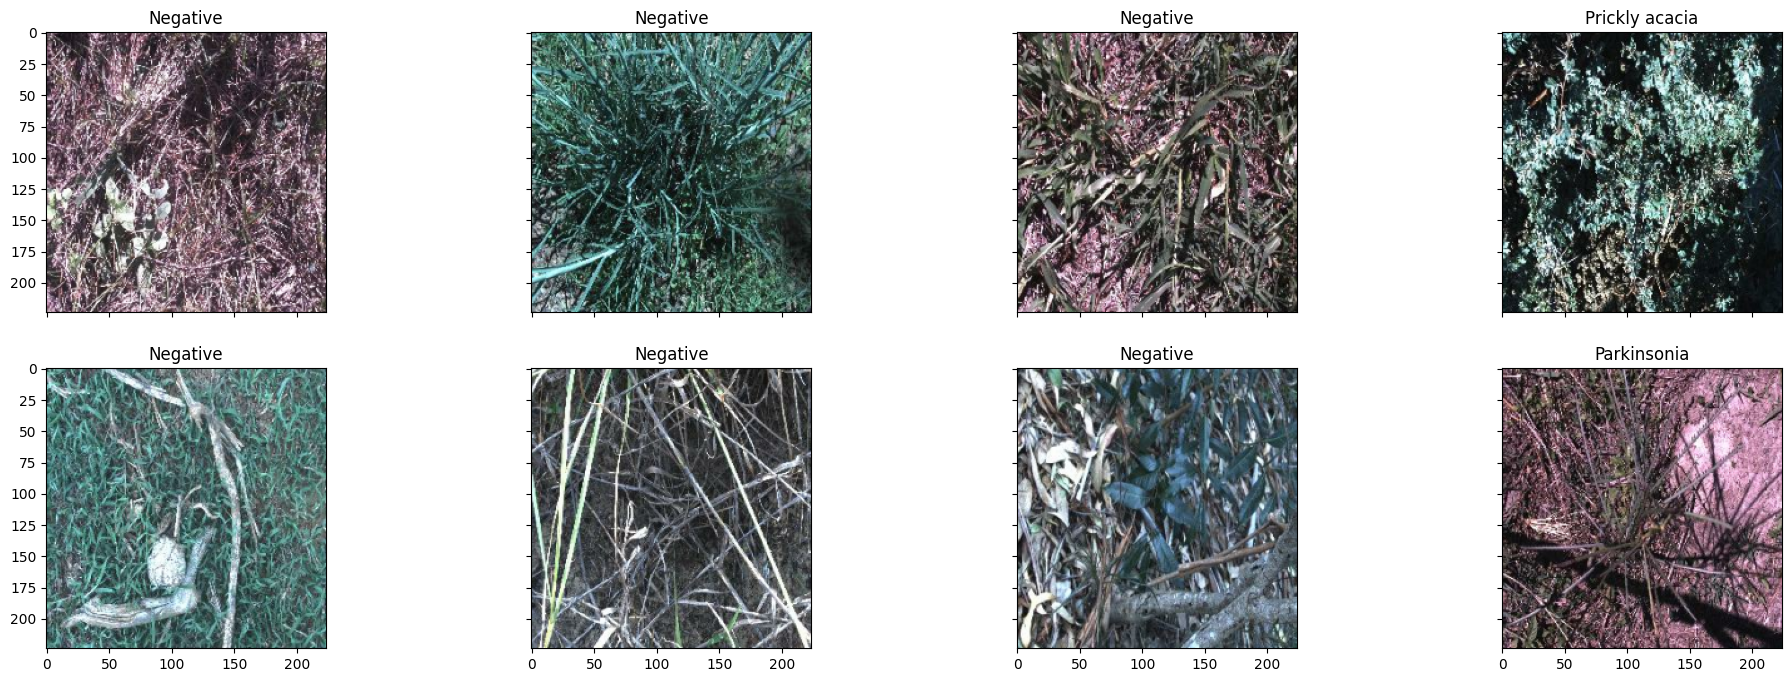

In [16]:
#image visualization
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 4, sharex=True, sharey=True, figsize=(24,8))

for images, labels in validation_generator:
    for i in range(2):
        for j in range(4):
            ax[i][j].imshow(images[i+j*2].numpy().astype(np.int32))
            ax[i][j].set_title(id2label[np.argmax(labels[i+j*2])])

    break
plt.show()

In [17]:
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras.layers as layers
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, MaxPool2D, Reshape, \
                        Dense, multiply, Permute, Concatenate, Conv2D, Add, Activation, Lambda, Average
from tensorflow.keras import backend as K
from tensorflow.keras.activations import sigmoid, softmax

def hard_sigmoid(x):
    relu6 = layers.ReLU(max_value=6)
    return relu6(x + 3) / 6
    
def hard_swish(x):
    return x * hard_sigmoid(x)

def GlobalAverageOfMaximums(x, max_pool_size=2, layer_num=1, keep_out_dims=False):
    _max = layers.MaxPooling2D(pool_size=max_pool_size,padding='same', name="Maximums_L{}".format(layer_num))(x)
    _avg = layers.GlobalAveragePooling2D(name="Average_of_Maximums_L{}".format(layer_num), keepdims=keep_out_dims)(_max)
    return _avg

# ConvSelfAt10tion

In [18]:
class TiledUpSampler2D(tf.keras.layers.Layer):
    def __init__(self, **kwargs): ## pooling method: avg | max
        super().__init__(**kwargs)

    def build(self, input_shape):
        assert len(input_shape) == 4 ## asserting the input shape is [batch_size, height, width, channel]
        super().build(input_shape)

    def call(self, x):
        shape = x.shape

        pad = shape[2]//2
        t = shape[2] - pad
        w = shape[2] + (2*pad)
        h = shape[1]
        
        _x = tf.tile(x,tf.constant([1,1,3,1]))
        _x = tf.image.crop_to_bounding_box(_x, 0, t, h, w)

        pad = shape[1]//2
        h = shape[1] + (2*pad)
        t = shape[1] - pad
        _x = tf.tile(_x,tf.constant([1,3,1,1]))
        _x = tf.image.crop_to_bounding_box(_x, t, 0, h, w)
        
        return _x


def ConvSelfAt10tion(in_x, dropout=0.05, upsample=True, double_kernel=False):
    avg_x = tf.keras.layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(in_x)
    max_x = tf.keras.layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(in_x)
    avg_max = tf.keras.layers.Concatenate(axis=-1)([avg_x, max_x])
    x = tf.keras.layers.Dropout(dropout, seed=SEED)(avg_max)

    if upsample and not double_kernel:
        upsampler = TiledUpSampler2D()
        x = upsampler(x)
    
    padding = 'same' if (x.shape[1] == in_x.shape[1] or double_kernel) else 'valid'
    Kernel = (in_x.shape[1]*2) - 1 if double_kernel else in_x.shape[1]
    
    q = tf.keras.layers.Conv2D(1, Kernel, padding=padding, use_bias=False, kernel_initializer=tf.keras.initializers.HeUniform(SEED))(x)
    k = tf.keras.layers.Conv2D(in_x.shape[-1], 3, padding='same', activation='sigmoid', groups=in_x.shape[-1], use_bias=False, kernel_initializer=tf.keras.initializers.HeUniform(SEED), kernel_regularizer=keras.regularizers.L1L2(0.0001,0.001))(in_x)
    
    x = k * q
    return x

In [19]:
def subSpaceBottleneckFCLayer(in_shape, n_spaces = 8, out_feat_size = 1024, keep_dims = True):
    final_out = out_feat_size // n_spaces
    interm_out = final_out*2

    out_layer = None
    reshape = (n_spaces, -1)
    if keep_dims:
        out_shape = [*in_shape[:-1], -1]
        out_layer = layers.Reshape(out_shape)
        reshape = [*in_shape[:-1], n_spaces, -1]
    else:
        out_layer = layers.Flatten()
    
    bottleneck_layer = keras.Sequential([
        layers.Input(in_shape),
        layers.Reshape(reshape, name="SubspaceFC_Reshape"),
        layers.Dense(final_out, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed), name="SubspaceFC_Base"),
        layers.Dense(interm_out, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed), name="SubspaceFC_Bottleneck_Expand"),
        layers.Dense(final_out, use_bias=False, kernel_regularizer=keras.regularizers.L1L2(0.001,0.01), name="SubspaceFC_Bottleneck_Compress"),
        out_layer,
        layers.Dropout(0.3, seed=SEED, name="SubspaceFC_Dropout")
    ], name='Subspace_Bottleneck_FCLayer')
    bottleneck_layer.summary()
    
    return bottleneck_layer

# Building MobileNet Model

In [20]:
from tensorflow.keras.applications import MobileNet, MobileNetV2, MobileNetV3Small, MobileNetV3Large
from tensorflow.keras.applications import ResNet50V2 as resnet
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2B0

def augment(seed=42):
    augs = [] if isTPU else [layers.RandomRotation(0.5, seed=seed, name='RR_Rot'), 
                            layers.RandomTranslation(0.4, 0.4, seed=seed, name='RR_Trans'),
                            layers.RandomZoom(0.2, 0.2, seed=seed, name='RR_Zoom'),] ## can't run with TPU
    
    aug_model = keras.Sequential([
        layers.Input(IMG_SIZE),
        layers.RandomBrightness(0.3, (0, 1),seed=seed, name='RR_Bright'),
        # layers.RandomContrast(0.3, seed=seed, name='RR_Contr'), # can't run deterministically
        layers.RandomFlip(seed=seed, name='RR_Flip'),
        *augs,
        layers.GaussianNoise(0.01, seed=SEED, name='RR_GNoise'),
        # layers.GaussianDropout(0.01, seed=seed, name='RR_Gauss'),
    ], name='augment_pipeline')
    aug_model.summary()
    
    return aug_model


def skipAugment(model):
    inputs = keras.Input(shape=IMG_SIZE)
    x = inputs
    for layer in model.layers:
        if 'augment' not in layer.name and 'input' not in layer.name:
            x = layer(x)

    model = keras.Model(inputs=inputs, outputs=x, name=model.name)
    return model

def loadEfficientNetModelForTraining(model):
    base_index = 0
    for i in range(len(model.layers)):
        if('conv' in model.layers[i].name):
            base_index = i
            break

    preprocess_layer = None
    if base_index in [0, 1]:
        model = keras.Model(inputs= model.layers[0].output, outputs=model.layers[-1].output, name = model.name+"_base_")
        return model, preprocess_layer
    else:
        preprocess_layer =  keras.Model(inputs=model.layers[0].output, outputs=model.layers[base_index-1].output, name = "preprocess_layer_"+model.name)
    
    in_layer = model.layers[base_index]
    base_model =  keras.Model(inputs=in_layer.input, outputs=model.layers[-1].output, name = model.name+"_base_")
    return base_model, preprocess_layer
    

def buildModel(IMG_SIZE, skip_preprocess=False, embed_conv_self_attn=False, embed_subspace_fc=False):
    # Load the MobileNet model with weights pre-trained on ImageNet.
    base_model = EfficientNetV2B0(input_shape=IMG_SIZE, weights='imagenet', include_top=False, include_preprocessing=False)
    # base_model, pre_layer = loadEfficientNetModelForTraining(base_model)
    
    print("Base Model:", base_model.name)
    print(len(base_model.layers))
    # base_model.summary()
    
    # Define the input layer.
    inputs = keras.Input(shape=IMG_SIZE, name='input')
    x = inputs
    
    # Pre-process the input.
    if not skip_preprocess:
        x = layers.Resizing(IMG_SIZE[0], IMG_SIZE[1], name='PP_Resize')(x)
        x = layers.Rescaling(1./255, name='PP_Rescale_down')(x)
    
        x = augment(seed)(x)
    else:
        x = inputs
    
    x = base_model(x, training=True)
    
    # if embed_conv_self_attn:
    #     _x = layers.Dropout(0.1, seed=SEED)(x) 
    #     x = ConvSelfAt10tion(_x, upsample=False)
        
    x = layers.GlobalAveragePooling2D(keepdims=False)(x)
    x = layers.Dropout(0.3, seed=SEED)(x) 

    # if embed_subspace_fc:
    #     x = subSpaceBottleneckFCLayer(x.shape[1:], NUM_SPACES, FINAL_FEAT_SIZE, False)(x)
    
    outputs = layers.Dense(9, activation='softmax')(x)
    model_name = "DeepWeeds-" + base_model.name
    
    # Create the model.
    model = keras.Model(inputs=inputs, outputs=outputs, name=model_name)
    return model

In [21]:
with strategy.scope():
    model = buildModel(IMG_SIZE, False, False, False)
model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Base Model: efficientnetv2-b0
268


Model: "augment_pipeline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ RR_Bright (RandomBrightness)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RR_Flip (RandomFlip)            │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RR_Rot (RandomRotation)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RR_Trans (RandomTranslation)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RR_Zoom (RandomZoom)            │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RR_GNoise (GaussianNoise)       │ (None, 224, 224, 3)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

Model: "DeepWeeds-efficientnetv2-b0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ PP_Resize (Resizing)            │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ PP_Rescale_down (Rescaling)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment_pipeline (Sequential)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,930,841 (22.62 MB)

 Trainable params: 5,870,233 (22.39 MB)

 Non-trainable params: 60,608 (236.75 KB)

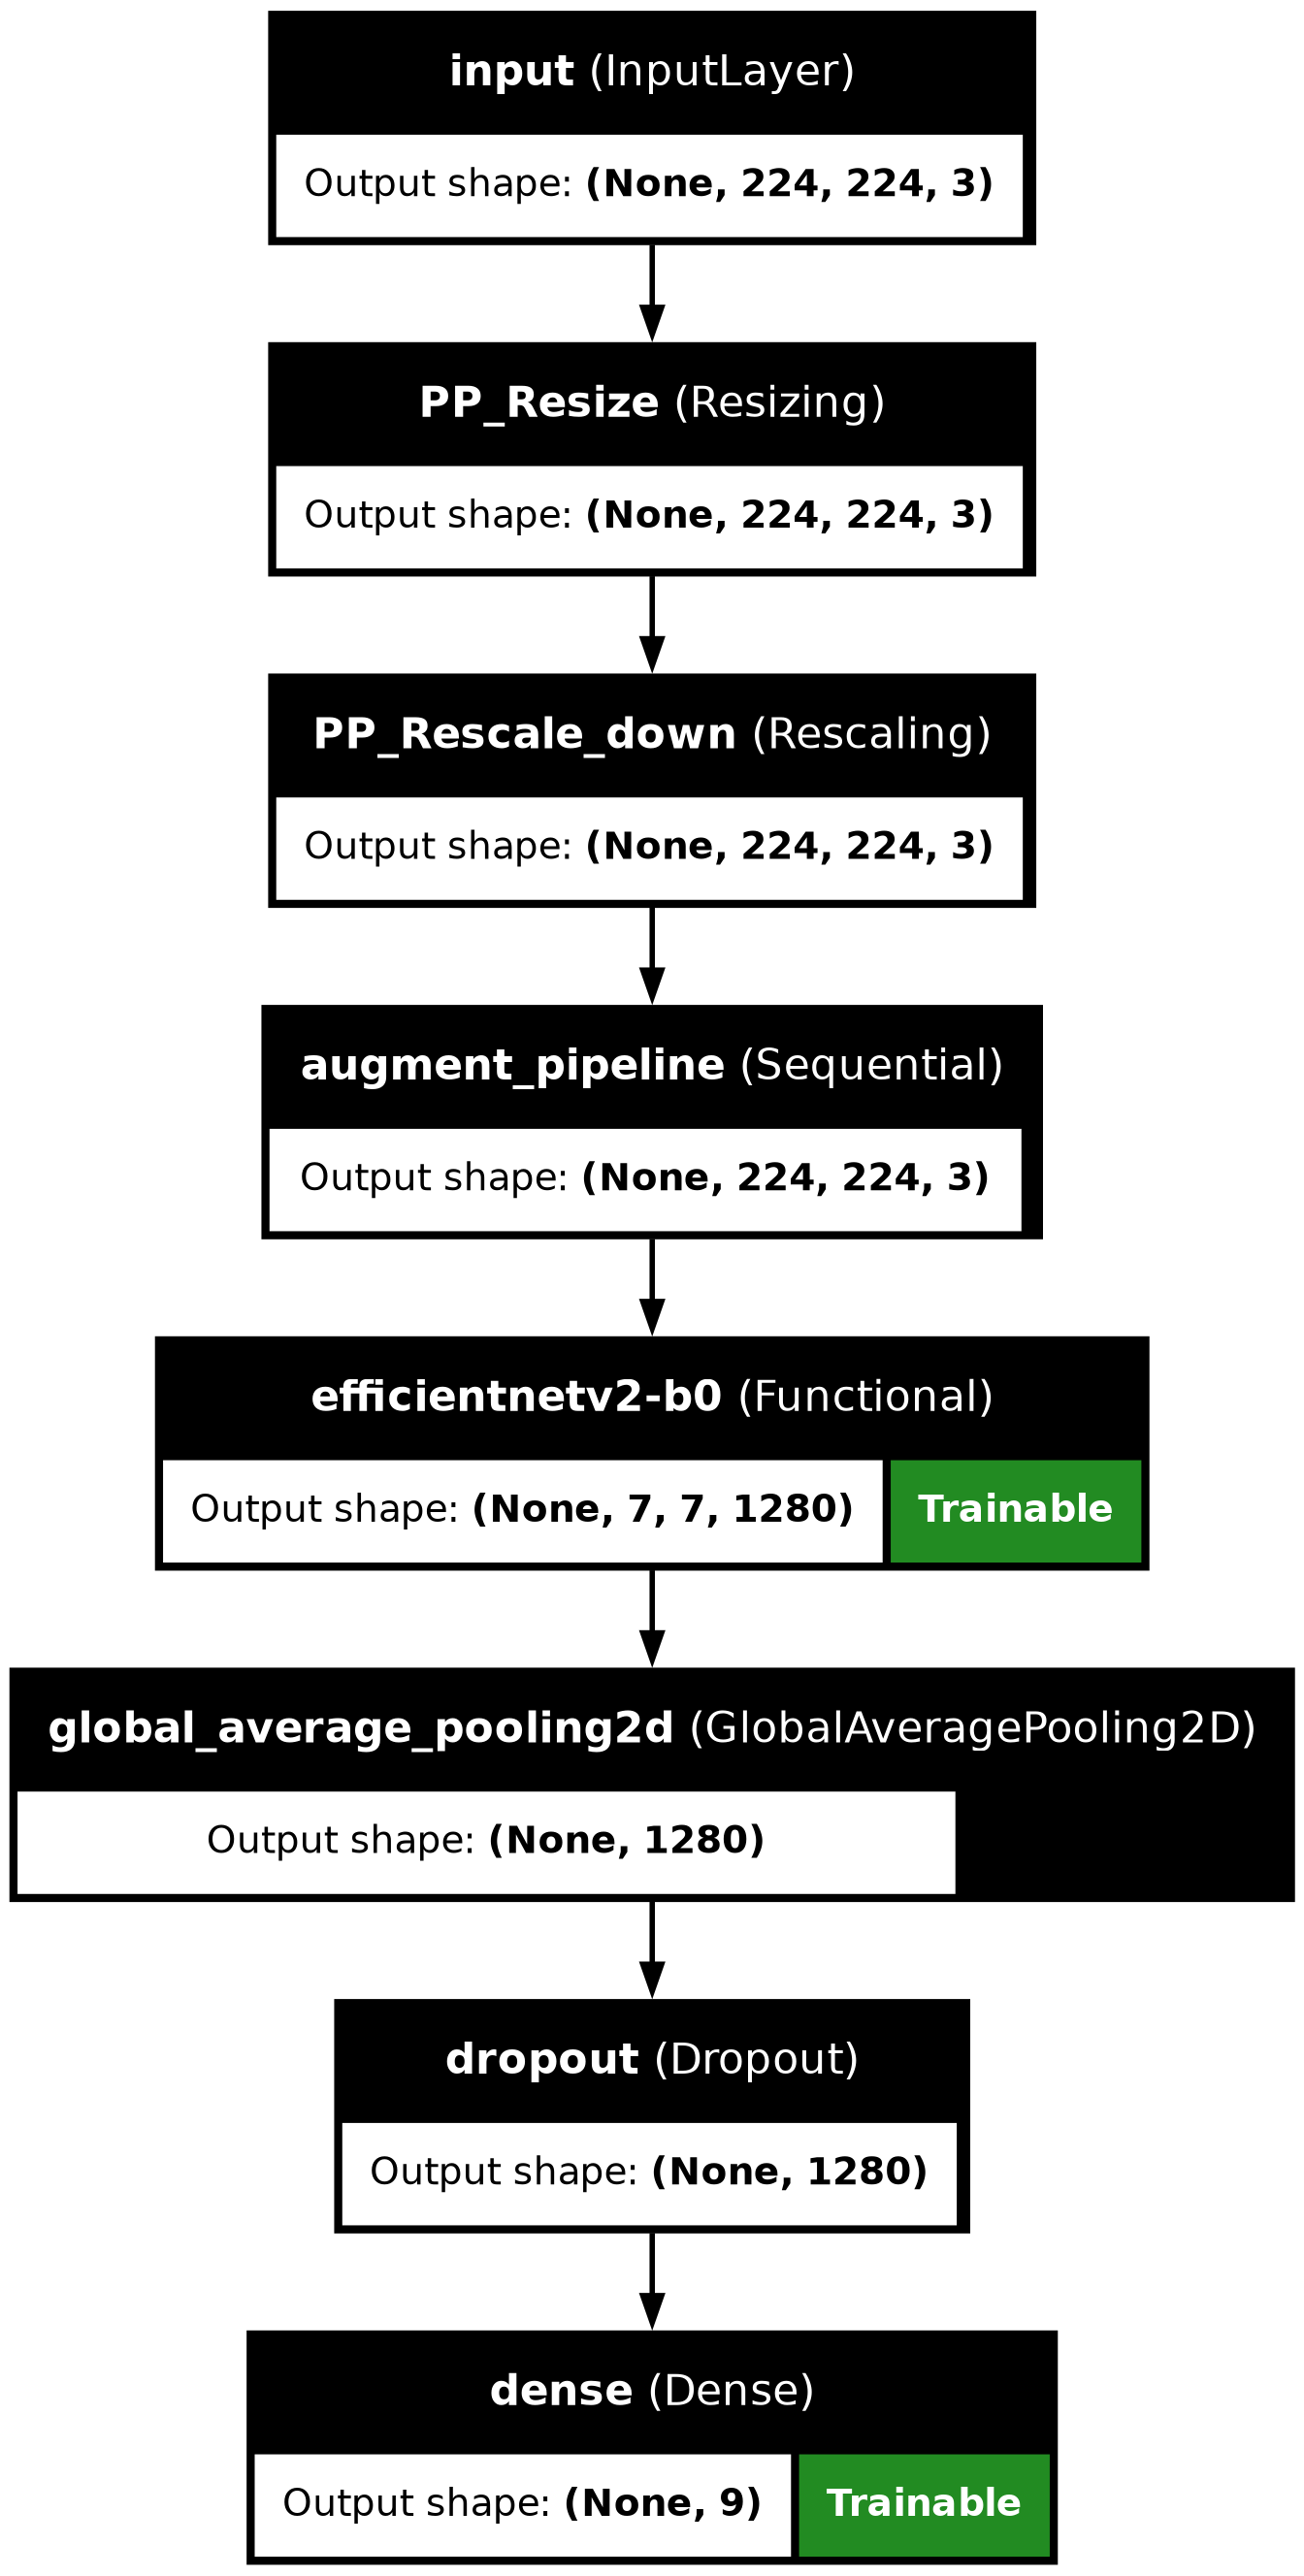

In [22]:
tf.keras.utils.plot_model(model, show_trainable=True, show_layer_names=True, show_shapes=True)

# Trial 1 - FineTuning

In [23]:
from tensorflow.keras.optimizers import Adam, AdamW

checkpoint = tf.keras.callbacks.ModelCheckpoint(MODEL_NAME, save_best_only=True, monitor=ES_MONITOR)
with strategy.scope():
    loss = tf.keras.losses.CategoricalFocalCrossentropy()
    optimizer = Adam(learning_rate=(WARMUP_INIT_LR if USE_WARMUP else INIT_LR1),  weight_decay=W_DECAY1, clipnorm=1.0) if not USE_ADAMW else AdamW(learning_rate=(WARMUP_INIT_LR if USE_WARMUP else INIT_LR1),  weight_decay=W_DECAY1)
    
    model.compile(loss=loss,
              optimizer=optimizer,
              metrics=['accuracy'])

    early_stopping = tf.keras.callbacks.EarlyStopping(monitor=ES_MONITOR, patience=ES_PATIENCE, verbose=1, restore_best_weights=True)
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=LR_REDUCTION_FACTOR, patience=LR_REDUCTION_PATIENCE, verbose=1, min_lr=MIN_LR1)

    def createWarmUpScheduler(epochs=5, inc_rate=0.5, init_lr=2e-6, final_lr=2e-5):
        def scheduler(e, lr):
            if e < epochs:
                new_lr =  lr + (lr * inc_rate)
                return new_lr if new_lr < final_lr else final_lr
            elif e == epochs:
                return final_lr
            else:
                return lr

        return scheduler
        
    warmup = keras.callbacks.LearningRateScheduler(createWarmUpScheduler(WARMUP_EPOCHS, WARMUP_INCREMENT_RATE, WARMUP_INIT_LR, INIT_LR1))

    callbacks = [checkpoint, early_stopping, reduce_lr] + ([warmup] if USE_WARMUP else [])
    print(len(callbacks))

print(model.optimizer.get_config())

4
{'name': 'adamw', 'learning_rate': 3.9999998989515007e-05, 'weight_decay': 0.05, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}


Epoch 1/300


2026-02-21 03:24:04.512282: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DeepWeeds-efficientnetv2-b0_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


329/329 ━━━━━━━━━━━━━━━━━━━━ 115s 210ms/step - accuracy: 0.3357 - loss: 0.3562 - val_accuracy: 0.5770 - val_loss: 0.2320 - learning_rate: 5.2000e-05
Epoch 2/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 67s 202ms/step - accuracy: 0.6382 - loss: 0.1691 - val_accuracy: 0.6530 - val_loss: 0.1571 - learning_rate: 6.7600e-05
Epoch 3/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 66s 201ms/step - accuracy: 0.7359 - loss: 0.1083 - val_accuracy: 0.7232 - val_loss: 0.1209 - learning_rate: 8.7880e-05
Epoch 4/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 66s 200ms/step - accuracy: 0.7800 - loss: 0.0834 - val_accuracy: 0.8335 - val_loss: 0.0723 - learning_rate: 1.1424e-04
Epoch 5/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 66s 201ms/step - accuracy: 0.8164 - loss: 0.0683 - val_accuracy: 0.8440 - val_loss: 0.0615 - learning_rate: 1.4852e-04
Epoch 6/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 66s 201ms/step - accuracy: 0.8399 - loss: 0.0593 - val_accuracy: 0.8612 - val_loss: 0.0603 - learning_rate: 2.0000e-04
Epoch 7/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 66s 200ms/

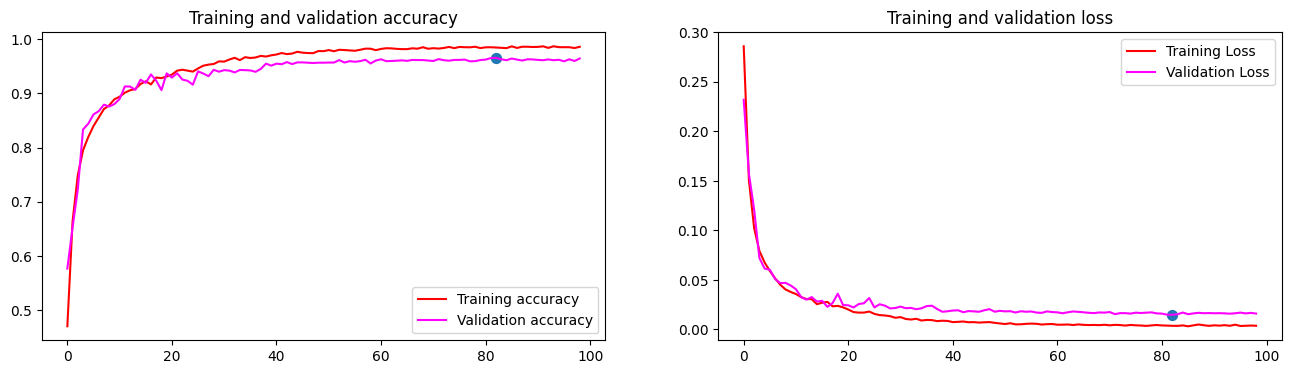

CPU times: user 2h 18min 53s, sys: 16min 9s, total: 2h 35min 2s
Wall time: 1h 49min 10s


In [24]:
%%time
# Train the model
with strategy.scope():
    history1 = model.fit(
          train_generator,
          epochs=EPOCHS,
          validation_data=validation_generator,
          callbacks=callbacks,
        )

    # Plot training results
    plot_loss_acc(history1.history)

# Evaluation#1


Validation Set Statistics
model.evaluate
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9629 - loss: 0.0172
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.94444   0.90667   0.92517       225
       Lantana    0.95775   0.95775   0.95775       213
   Parkinsonia    0.96135   0.96602   0.96368       206
    Parthenium    0.97512   0.96078   0.96790       204
Prickly acacia    0.95215   0.93868   0.94537       212
   Rubber vine    0.98500   0.97525   0.98010       202
     Siam weed    0.96789   0.98140   0.97460       215
    Snake weed    0.93401   0.90640   0.92000       203
      Negative    0.97065   0.98078   0.97569      1821

      accuracy                        0.96544      3501
     macro avg    0.96093   0.95264   0.95669      3501
  weighted avg    0.96531   0.96544   0.96531      3501


                False Positive Rate  Accuracy
Chinee apple               0.003663  0.906667
Lantana                    0.002737  0.957746
Parkinsonia                0.002428  0.966019
Parthenium                 0.001517  0.960784
Prickly acacia    

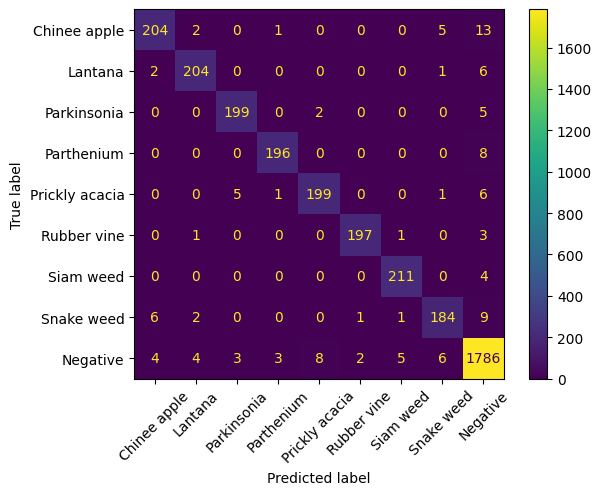


Testn Set Statistics
model.evaluate
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9429 - loss: 0.0205
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.93333   0.86726   0.89908       226
       Lantana    0.94931   0.96714   0.95814       213
   Parkinsonia    0.96714   0.99517   0.98095       207
    Parthenium    0.95215   0.97073   0.96135       205
Prickly acacia    0.95238   0.93897   0.94563       213
   Rubber vine    0.96020   0.95545   0.95782       202
     Siam weed    0.98165   0.99535   0.98845       215
    Snake weed    0.92462   0.90196   0.91315       204
      Negative    0.97541   0.97969   0.97755      1822

      accuracy                        0.96464      3507
     macro avg    0.95513   0.95241   0.95357      3507
  weighted avg    0.96442   0.96464   0.96441      3507


                False Positive Rate  Accuracy
Chinee apple               0.004267  0.867257
Lantana                    0.003339  0.967136
Parkinsonia                0.002121  0.995169
Parthenium                 0.003028  0.970732
Prickly acacia    

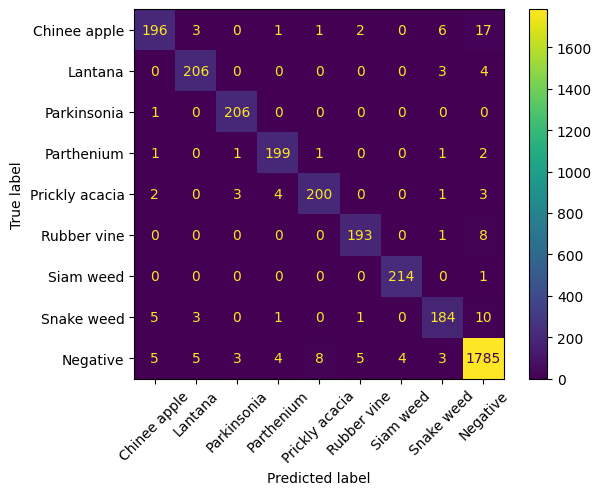

In [25]:
print("\nValidation Set Statistics")
a, b = eval_model(model, validation_generator)

print("\nTestn Set Statistics")
a, b = eval_model(model, test_generator)

# Freezing Base Model

In [26]:
with strategy.scope():
    for layer in model.layers:
        name = layer.name.lower()
        if "efficientnet" in name:
            print("Freezing layer", layer.name, layer.trainable)
            layer.trainable = False

Freezing layer efficientnetv2-b0 True


# Evaluations #1.1b

Test After Freezing
Train Set Statistics
model.evaluate
329/329 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.9956 - loss: 0.0011
model.predict


  0%|          | 0/329 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.99553   0.98963   0.99257       675
       Lantana    0.99687   1.00000   0.99843       637
   Parkinsonia    0.99197   1.00000   0.99597       618
    Parthenium    0.99674   0.99837   0.99756       613
Prickly acacia    0.99215   0.99215   0.99215       637
   Rubber vine    0.99671   1.00000   0.99835       605
     Siam weed    0.99536   0.99845   0.99690       644
    Snake weed    0.98379   0.99672   0.99021       609
      Negative    0.99835   0.99542   0.99688      5463

      accuracy                        0.99610     10501
     macro avg    0.99416   0.99675   0.99545     10501
  weighted avg    0.99611   0.99610   0.99610     10501


                False Positive Rate  Accuracy
Chinee apple               0.000305  0.989630
Lantana                    0.000203  1.000000
Parkinsonia                0.000506  1.000000
Parthenium                 0.000202  0.998369
Prickly acacia    

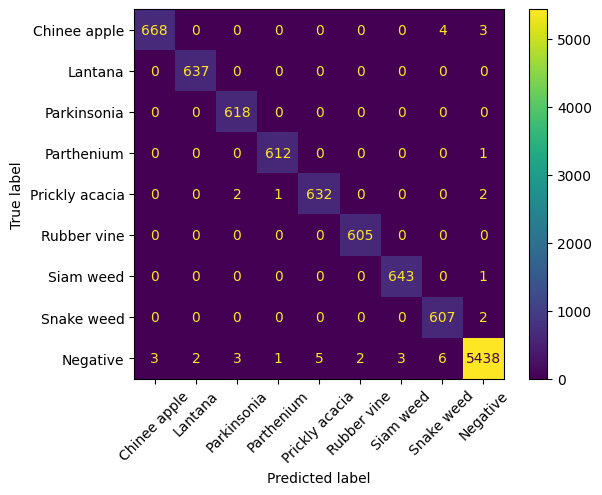

Validation Set Stats
model.evaluate
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9634 - loss: 0.0178
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.94444   0.90667   0.92517       225
       Lantana    0.95775   0.95775   0.95775       213
   Parkinsonia    0.96135   0.96602   0.96368       206
    Parthenium    0.97512   0.96078   0.96790       204
Prickly acacia    0.95215   0.93868   0.94537       212
   Rubber vine    0.98500   0.97525   0.98010       202
     Siam weed    0.96789   0.98140   0.97460       215
    Snake weed    0.93401   0.90640   0.92000       203
      Negative    0.97065   0.98078   0.97569      1821

      accuracy                        0.96544      3501
     macro avg    0.96093   0.95264   0.95669      3501
  weighted avg    0.96531   0.96544   0.96531      3501


                False Positive Rate  Accuracy
Chinee apple               0.003663  0.906667
Lantana                    0.002737  0.957746
Parkinsonia                0.002428  0.966019
Parthenium                 0.001517  0.960784
Prickly acacia    

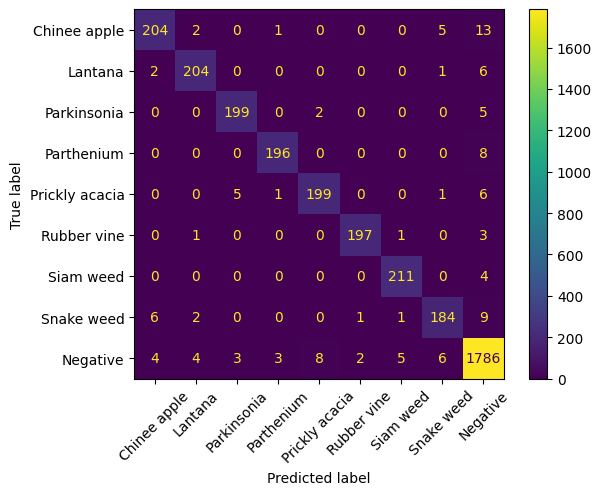

Test Set Stats
model.evaluate
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9429 - loss: 0.0205
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.93333   0.86726   0.89908       226
       Lantana    0.94931   0.96714   0.95814       213
   Parkinsonia    0.96714   0.99517   0.98095       207
    Parthenium    0.95215   0.97073   0.96135       205
Prickly acacia    0.95238   0.93897   0.94563       213
   Rubber vine    0.96020   0.95545   0.95782       202
     Siam weed    0.98165   0.99535   0.98845       215
    Snake weed    0.92462   0.90196   0.91315       204
      Negative    0.97541   0.97969   0.97755      1822

      accuracy                        0.96464      3507
     macro avg    0.95513   0.95241   0.95357      3507
  weighted avg    0.96442   0.96464   0.96441      3507


                False Positive Rate  Accuracy
Chinee apple               0.004267  0.867257
Lantana                    0.003339  0.967136
Parkinsonia                0.002121  0.995169
Parthenium                 0.003028  0.970732
Prickly acacia    

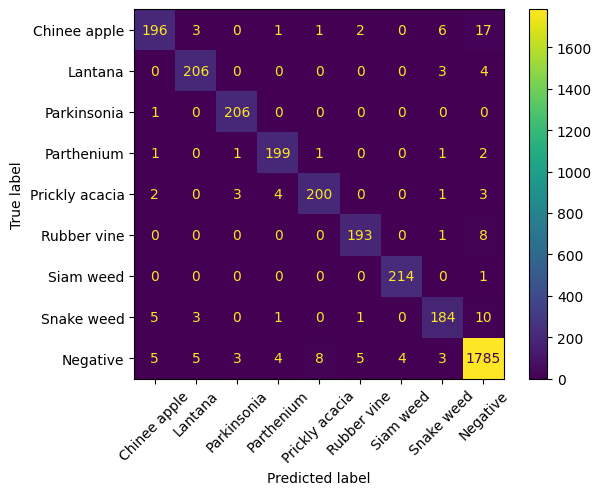

In [27]:
## Test After Freezing
print("Test After Freezing")

print("Train Set Statistics")
a, b = eval_model(model, train_generator)

print("Validation Set Stats")        
a, b = eval_model(model, validation_generator)

print("Test Set Stats")
a, b = eval_model(model, test_generator)

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.86722   0.92478   0.89507       226
       Lantana    0.84615   0.98122   0.90870       213
   Parkinsonia    0.96714   0.99517   0.98095       207
    Parthenium    0.95215   0.97073   0.96135       205
Prickly acacia    0.89823   0.95305   0.92483       213
   Rubber vine    0.96482   0.95050   0.95761       202
     Siam weed    0.97273   0.99535   0.98391       215
    Snake weed    0.92462   0.90196   0.91315       204
      Negative    0.98574   0.94841   0.96671      1822

      accuracy                        0.95352      3507
     macro avg    0.93098   0.95791   0.94359      3507
  weighted avg    0.95569   0.95352   0.95397      3507


                False Positive Rate  Accuracy
Chinee apple               0.009753  0.924779
Lantana                    0.011536  0.981221
Parkinsonia                0.002121  0.995169
Parthenium                 0.003028  0.970732
Prickly acacia    

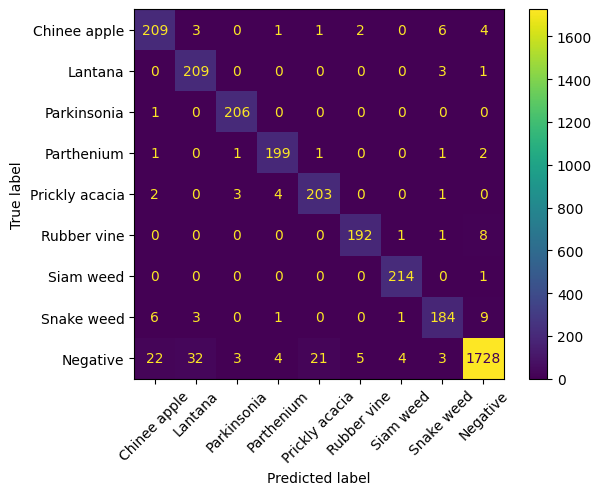

In [28]:
printStats(a,b,0.11)

# Trial 2

In [29]:
with strategy.scope():
    loss = tf.keras.losses.CategoricalFocalCrossentropy()
    optimizer = Adam(learning_rate=INIT_LR2,  weight_decay=W_DECAY2, clipnorm=2.0) if not USE_ADAMW else AdamW(learning_rate=INIT_LR2,  weight_decay=W_DECAY2)
  
    model.compile(loss=loss,
              optimizer=optimizer,
              metrics=['accuracy'])

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor=ES_MONITOR, factor=LR_REDUCTION_FACTOR, patience=LR_REDUCTION_PATIENCE, verbose=1, min_lr=MIN_LR2)


print(model.optimizer.get_config())

{'name': 'adamw', 'learning_rate': 1.9999999494757503e-05, 'weight_decay': 0.005, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}


Epoch 1/60


2026-02-21 05:17:57.250451: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DeepWeeds-efficientnetv2-b0_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


329/329 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.9921 - loss: 0.0022 - val_accuracy: 0.9649 - val_loss: 0.0150 - learning_rate: 2.0000e-05
Epoch 2/60
329/329 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - accuracy: 0.9918 - loss: 0.0027 - val_accuracy: 0.9643 - val_loss: 0.0153 - learning_rate: 2.0000e-05
Epoch 3/60
329/329 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - accuracy: 0.9922 - loss: 0.0022 - val_accuracy: 0.9640 - val_loss: 0.0156 - learning_rate: 2.0000e-05
Epoch 4/60
328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9942 - loss: 0.0018
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.5999999595806004e-05.
329/329 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - accuracy: 0.9942 - loss: 0.0018 - val_accuracy: 0.9640 - val_loss: 0.0153 - learning_rate: 2.0000e-05
Epoch 5/60
329/329 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - accuracy: 0.9922 - loss: 0.0020 - val_accuracy: 0.9632 - val_loss: 0.0154 - learning_rate: 1.6000e-05
Epoch 6/60
329/329 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - accuracy: 0.

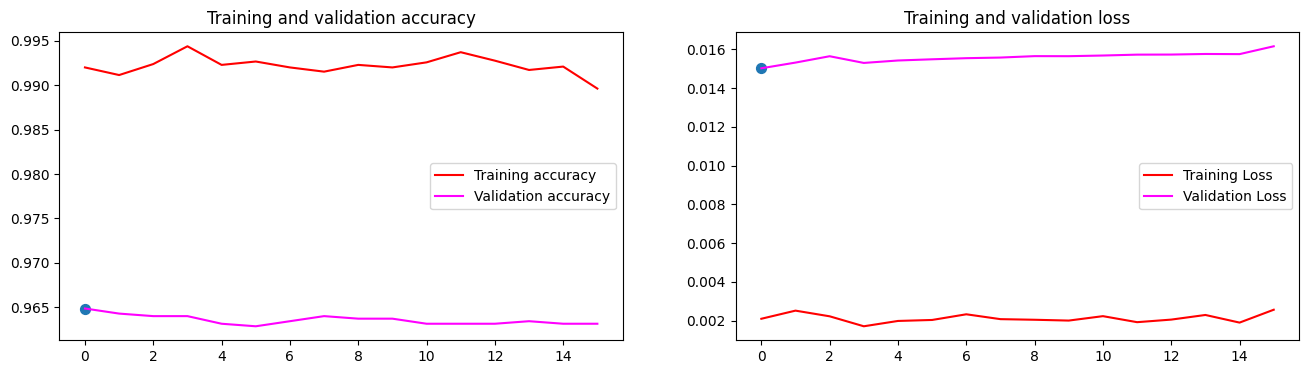

In [30]:
# Train the model

with strategy.scope():
    history2 = model.fit(
          train_generator,
          epochs=EPOCHS//5,
          validation_data=validation_generator,
          callbacks=[early_stopping,reduce_lr]
        )

print("Saving the Checkpoint")
model.save("At10tion-"+MODEL_NAME)

# Plot training results
plot_loss_acc(history2.history)

# Accuracy / Loss Plots

Total Epochs: range(0, 115)


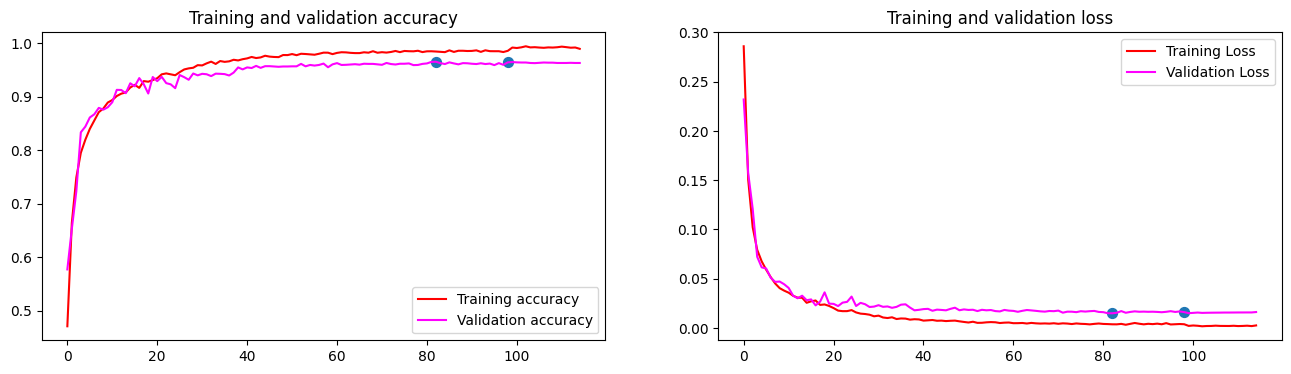

In [31]:
import copy

history = copy.deepcopy(history1.history)

for key in history:
    history[key].extend(history2.history[key])


h1len = len(history1.history['accuracy'])
h2len = len(history2.history['accuracy'])

pat_es = ES_PATIENCE + 1
history['peaks'] = [h1len-pat_es, (h1len+h2len)-pat_es]
history['peaks'] = [i if i>=0 else 0 for i in history['peaks']]

plot_loss_acc(history)

Total Epochs: range(0, 99)


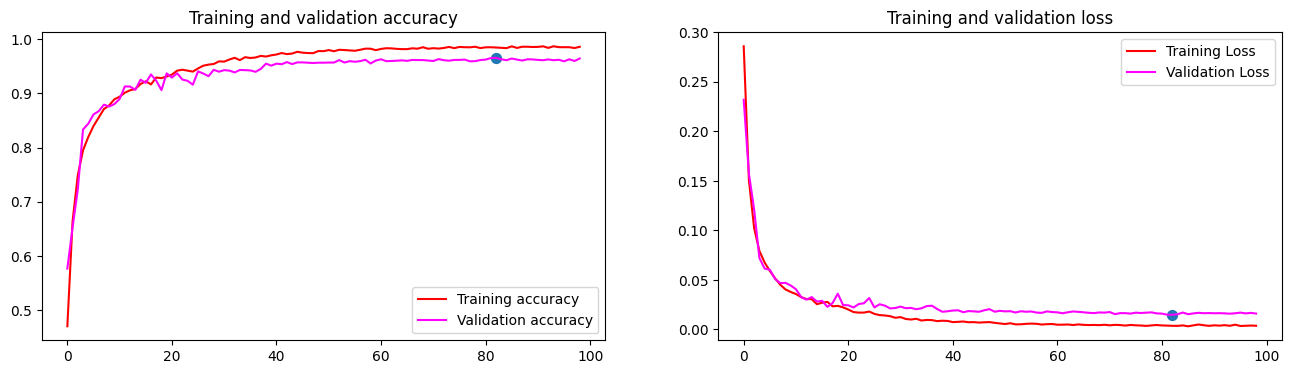

Total Epochs: range(0, 16)


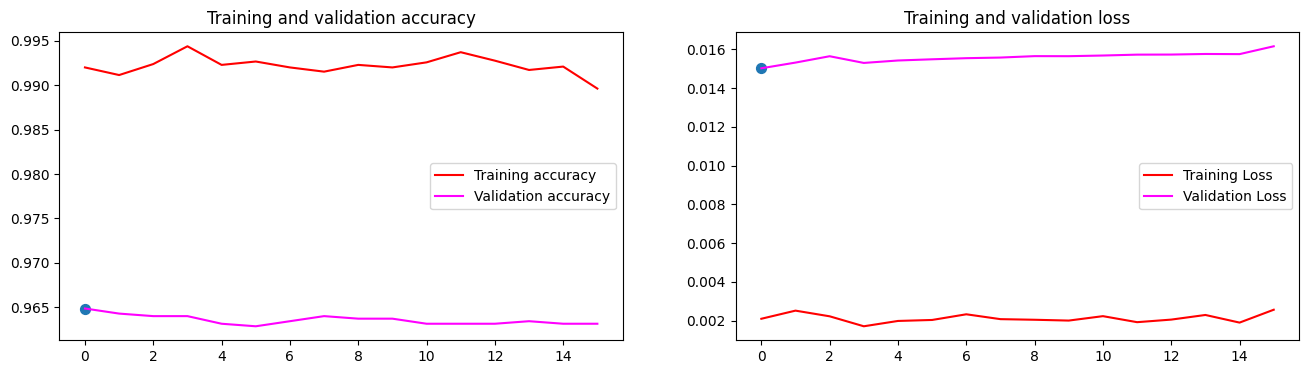

In [32]:
plot_loss_acc(history1.history)
plot_loss_acc(history2.history)

# Evaluation#2

Train Set Statistics
model.evaluate
329/329 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.9952 - loss: 0.0011
model.predict


  0%|          | 0/329 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.99552   0.98815   0.99182       675
       Lantana    0.99687   1.00000   0.99843       637
   Parkinsonia    0.99197   1.00000   0.99597       618
    Parthenium    0.99674   0.99837   0.99756       613
Prickly acacia    0.99214   0.99058   0.99136       637
   Rubber vine    0.99835   0.99835   0.99835       605
     Siam weed    0.99689   0.99689   0.99689       644
    Snake weed    0.98379   0.99672   0.99021       609
      Negative    0.99762   0.99579   0.99670      5463

      accuracy                        0.99591     10501
     macro avg    0.99443   0.99609   0.99525     10501
  weighted avg    0.99592   0.99591   0.99591     10501


                False Positive Rate  Accuracy
Chinee apple               0.000305  0.988148
Lantana                    0.000203  1.000000
Parkinsonia                0.000506  1.000000
Parthenium                 0.000202  0.998369
Prickly acacia    

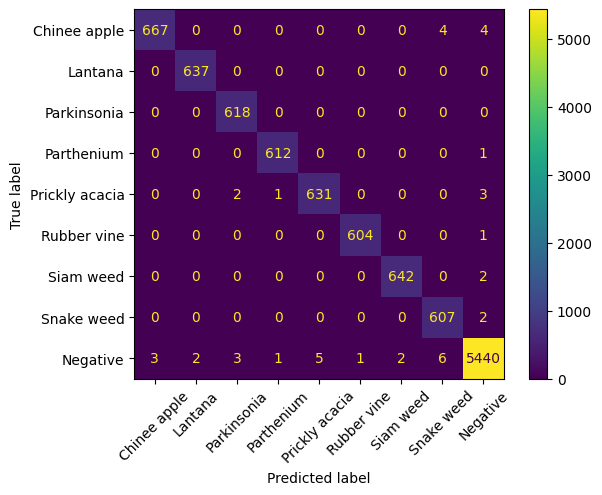


Validation Set Statistics
model.evaluate
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9631 - loss: 0.0173
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.94419   0.90222   0.92273       225
       Lantana    0.95775   0.95775   0.95775       213
   Parkinsonia    0.96135   0.96602   0.96368       206
    Parthenium    0.97512   0.96078   0.96790       204
Prickly acacia    0.95215   0.93868   0.94537       212
   Rubber vine    0.98995   0.97525   0.98254       202
     Siam weed    0.96774   0.97674   0.97222       215
    Snake weed    0.93367   0.90148   0.91729       203
      Negative    0.96909   0.98133   0.97517      1821

      accuracy                        0.96487      3501
     macro avg    0.96122   0.95114   0.95607      3501
  weighted avg    0.96474   0.96487   0.96472      3501


                False Positive Rate  Accuracy
Chinee apple               0.003663  0.902222
Lantana                    0.002737  0.957746
Parkinsonia                0.002428  0.966019
Parthenium                 0.001517  0.960784
Prickly acacia    

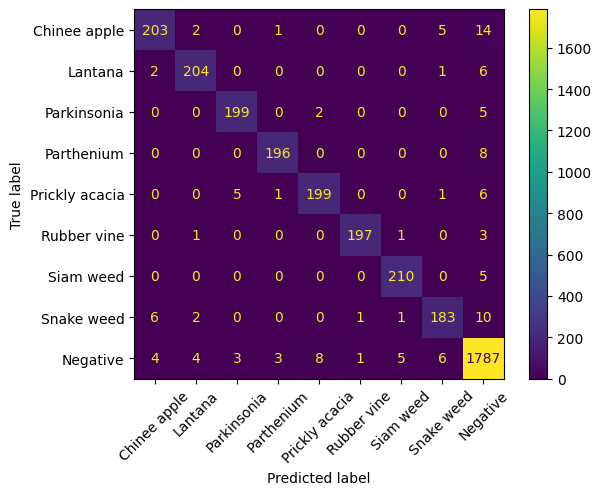


Testn Set Statistics
model.evaluate
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9425 - loss: 0.0206
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.93333   0.86726   0.89908       226
       Lantana    0.94931   0.96714   0.95814       213
   Parkinsonia    0.96714   0.99517   0.98095       207
    Parthenium    0.95673   0.97073   0.96368       205
Prickly acacia    0.95261   0.94366   0.94811       213
   Rubber vine    0.96482   0.95050   0.95761       202
     Siam weed    0.98618   0.99535   0.99074       215
    Snake weed    0.92347   0.88725   0.90500       204
      Negative    0.97331   0.98079   0.97704      1822

      accuracy                        0.96436      3507
     macro avg    0.95632   0.95087   0.95337      3507
  weighted avg    0.96409   0.96436   0.96409      3507


                False Positive Rate  Accuracy
Chinee apple               0.004267  0.867257
Lantana                    0.003339  0.967136
Parkinsonia                0.002121  0.995169
Parthenium                 0.002726  0.970732
Prickly acacia    

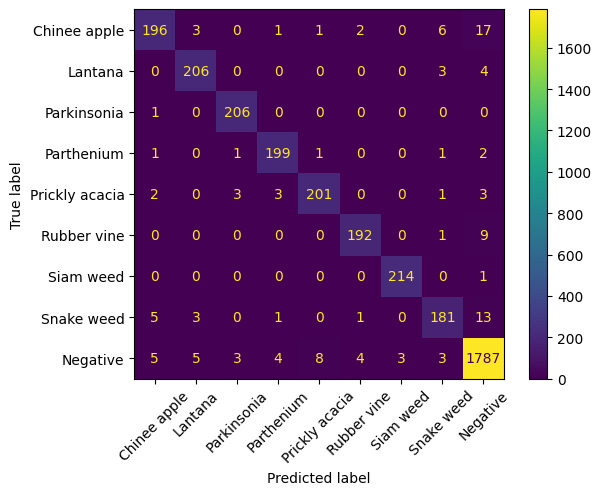

In [33]:
print("Train Set Statistics")
a, b = eval_model(model, train_generator)

print("\nValidation Set Statistics")
a, b = eval_model(model, validation_generator)

print("\nTestn Set Statistics")
a, b = eval_model(model, test_generator)

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.86777   0.92920   0.89744       226
       Lantana    0.85306   0.98122   0.91266       213
   Parkinsonia    0.96714   0.99517   0.98095       207
    Parthenium    0.95673   0.97073   0.96368       205
Prickly acacia    0.89868   0.95775   0.92727       213
   Rubber vine    0.96954   0.94554   0.95739       202
     Siam weed    0.97717   0.99535   0.98618       215
    Snake weed    0.92347   0.88725   0.90500       204
      Negative    0.98466   0.95115   0.96762      1822

      accuracy                        0.95438      3507
     macro avg    0.93314   0.95704   0.94424      3507
  weighted avg    0.95636   0.95438   0.95477      3507


                False Positive Rate  Accuracy
Chinee apple               0.009753  0.929204
Lantana                    0.010929  0.981221
Parkinsonia                0.002121  0.995169
Parthenium                 0.002726  0.970732
Prickly acacia    

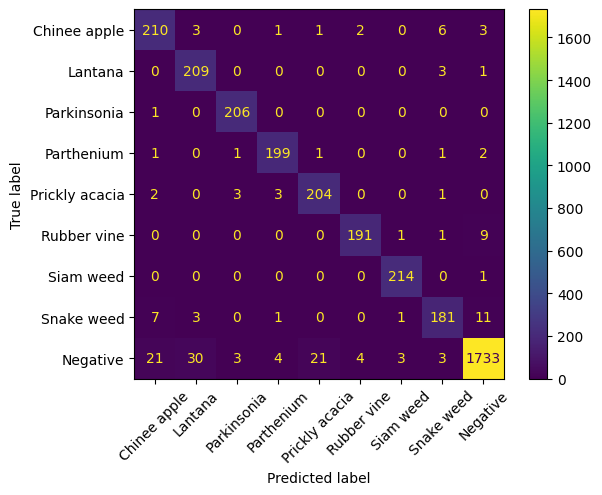

In [34]:
printStats(a,b,0.11)

## Clear Files

In [35]:
shutil.rmtree(base_dir)